# Hands-on 02: Caracterização do desvanecimento de pequena escala


## Parte 01: Separação dos desvanecimentos de Larga e Pequena escalas


### Objetivos
As metas desse tutorial são ajudar o usuário a:
- Gerar uma série temporal sintética com Perda de Percurso, Sombreamento e Desvanecimento m-Nakagami;
- Estimar cada desvanecimento por meio de regressão linear, filtragem e tratamento estatístico;
- Fazer gráficos e comparar as partes geradas sinteticamente e as partes estimadas.


## Prática 01: Criação do sinal sintético

Vamos escrever um código para criação de um sinal sintético com Perda de Percurso (modelo decaimento logaritmo), Sombreamento Log-Normal e Desvanecimento m-Nakagami. O código deve ser parametrizável e as séries temporais devem ser salvas em arquivo. Gráficos devem ilustrar o comportamento de cada parte do sinal sintético.


**Passo 01:** O código a seguir vai:

1. Criar a estrutura **sPar** de entrada de parâmetros;
2. Gerar um canal com desvanecimento de larga e pequena escalas;
3. A perda de percurso segue o modelo de log-linear com coeficiente de perda de percurso especificado por **sPar.n**.  geração da perda de percurso deve seguir as seguintes especificações:
 - O modelo da perda de percurso é $PL = P_0 + 10\cdot n\cdot log10(d/d_0)$, sendo $P_0$ a potência medida na distância de referência $d_0$, especificadas por **sPar.P0** e **sPar.d0**, respectivamente; 
 - A distância final da rota de medição é especificada por **sPar.totalLength** em metros;
 - O número de pontos de medição é especificado por **sPar.nPoints**;
4. O sombreamento $Xs$ segue um modelo log-normal com média zero e desvio padrão especificado por **sPar.sigma**. A geração do sombreamento deve seguir as seguintes especificações:
 - Amostras de sombreamento independentes devem sorteadas para pontos de medição em uma janela de **sPar.shadowingWindow**  amostras (isso quer dizer que depois de **sPar.shadowingWindow**  amostras, o sombreamento é descorrelacionado);
 - Amostras dentro de uma janela especificada por **sPar.shadowingWindow** devem ser iguais com intuito de modelar o sombreamento correlacionado; 
 - Para evitar variações brutas entre amostras independentes do sombreamento, um filtro média móvel com janela igual a **sPar.shadowingWindow** deve ser aplicado ao vetor de amostras de sombreamento;
 - Ajustes na média e no desvio padrão devem ser feitos para garantir seus valores amostrais;
5. O desvanecimento de pequena escala $Xf$ segue um modelo m-Nakagami com o valor de $m$ especificado por **sPar.m**. A geração do desvanecimento de pequena escala deve seguir as seguintes especificações:
 - A PDF da envoltória do sinal é m-Nakagami normalizada igual a $f(x; m) = \frac{2\cdot m^m}{\Gamma(m)}\cdot x^{2\cdot m-1} \cdot e^{-m\cdot x^2} $ [[fonte]](https://pdfs.semanticscholar.org/3e81/7c531d90f63a3c43fe7076189e942d6fed01.pdf);
5. Calcular a potência recebida como: $Prx = Ptx - PL + Xs + Xf$, todos em dB.

Canal sintetico:
   Media do sombreamento: 0.2268
   Std do sombreamento: 6.0667
   Janela de correlacao do sombreamento: 200 amostras
   Expoente de path loss: 4
   m de Nakagami: 4


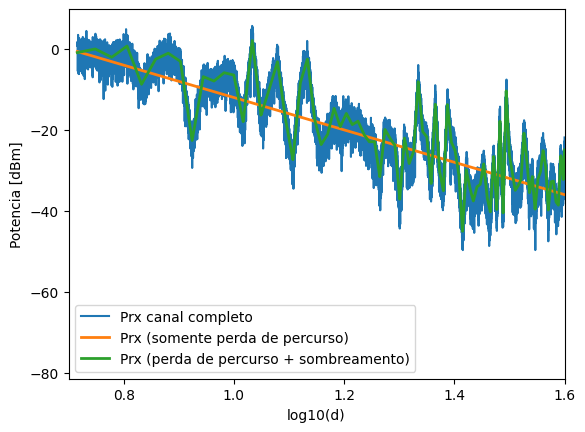

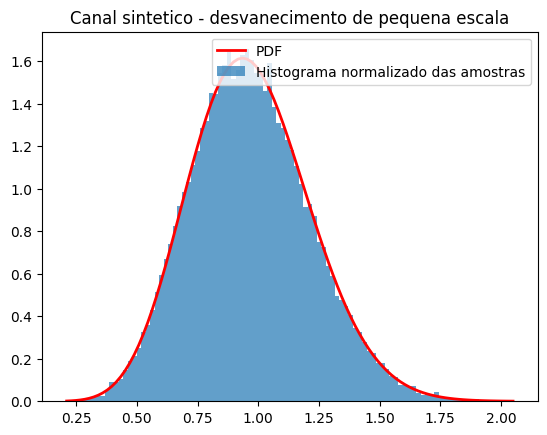

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nakagami
from scipy.io import savemat
from scipy.special import gamma

# Parametros para geracao do canal sintetico
sPar = {
    "d0": 5,
    "P0": 0,
    "nPoints": 50000,
    "totalLength": 100,
    "n": 4,
    "sigma": 6,
    "shadowingWindow": 200,
    "m": 4,
    "txPower": 0,
    "nCDF": 40,
    "chFileName": "Prx_sintetico",
}

# Distancia entre pontos de medicao
sPar["dMed"] = sPar["totalLength"] / sPar["nPoints"]

# Vetor de distancias do transmissor (alem da distancia de referencia)
vtDist = np.arange(sPar["d0"], sPar["totalLength"] + sPar["dMed"], sPar["dMed"])

# Numero de amostras geradas
nSamples = len(vtDist)

# Geracao da perda de percurso (deterministica)
vtPathLoss = sPar["P0"] + 10 * sPar["n"] * np.log10(vtDist / sPar["d0"])

# Geracao do sombreamento
nShadowSamples = nSamples // sPar["shadowingWindow"]
vtShadowing = sPar["sigma"] * np.random.randn(nShadowSamples)

# Amostras para a ultima janela
rest_len = nSamples % sPar["shadowingWindow"]
restShadowing = sPar["sigma"] * np.random.randn() * np.ones(rest_len)

# Repeticao do mesmo valor de sombreamento durante a janela de correlacao
vtShadowing = np.repeat(vtShadowing, sPar["shadowingWindow"])

# Amostras organizadas em um vetor
vtShadowing = np.concatenate([vtShadowing, restShadowing])

# Filtragem para evitar variacao abrupta do sombreamento (filtro media movel)
jan = sPar["shadowingWindow"] // 2
vtShadCorr = np.array([
    np.mean(vtShadowing[i - jan:i + jan + 1])
    for i in range(jan, nSamples - jan)
])

# Ajuste do desvio padrao depois do filtro de correlacao do sombreamento
vtShadCorr = vtShadCorr * np.std(vtShadowing) / np.std(vtShadCorr)
vtShadCorr = vtShadCorr - np.mean(vtShadCorr) + np.mean(vtShadowing)

# Geracao do desvanecimento de pequena escala: Nakagami fading
def fpNakaPdf(x, m=sPar["m"]):
    return ((2 * (m ** m)) / gamma(m)) * (x ** (2 * m - 1)) * np.exp(-m * (x ** 2))

# Gerador de numeros aleatorios com distribuicao Nakagami
vtNakagamiNormEnvelope = nakagami.rvs(sPar["m"], size=nSamples)

# Fading em dB (potencia)
vtNakagamiSampdB = 20 * np.log10(vtNakagamiNormEnvelope)

# Calculo da potencia recebida
vtTxPower = sPar["txPower"] * np.ones(nSamples)

# Ajuste do numero de amostras devido ao filtro de correlacao do sombreamento
vtTxPower = vtTxPower[jan:nSamples - jan]
vtPathLoss = vtPathLoss[jan:nSamples - jan]
vtFading = vtNakagamiSampdB[jan:nSamples - jan]
vtDist = vtDist[jan:nSamples - jan]

# Potencia recebida
vtPrx = vtTxPower - vtPathLoss + vtShadCorr + vtFading

# Salvamento dos dados
np.savetxt(
    sPar["chFileName"] + ".txt",
    np.column_stack((vtDist, vtPrx)),
    delimiter="\t",
)

savemat(
    sPar["chFileName"] + ".mat",
    {
        "vtDist": vtDist,
        "vtPathLoss": vtPathLoss,
        "vtShadCorr": vtShadCorr,
        "vtFading": vtFading,
        "vtPrx": vtPrx,
    },
)

# Mostra informacoes do canal sintetico
print("Canal sintetico:")
print(f"   Media do sombreamento: {np.mean(vtShadCorr):.4f}")
print(f"   Std do sombreamento: {np.std(vtShadCorr):.4f}")
print(f"   Janela de correlacao do sombreamento: {sPar['shadowingWindow']} amostras")
print(f"   Expoente de path loss: {sPar['n']}")
print(f"   m de Nakagami: {sPar['m']}")

# Plot do desvanecimento de larga escala (grafico linear)
plt.figure()
log_distancia = np.log10(vtDist)
plt.plot(log_distancia, vtPrx, label="Prx canal completo")
plt.plot(log_distancia, sPar["txPower"] - vtPathLoss, linewidth=2, label="Prx (somente perda de percurso)")
plt.plot(log_distancia, sPar["txPower"] - vtPathLoss + vtShadCorr, linewidth=2, label="Prx (perda de percurso + sombreamento)")
plt.xlabel("log10(d)")
plt.ylabel("Potencia [dBm]")
plt.legend()
plt.xlim([0.7, 1.6])

# Plot da geracao do desvanecimento Nakagami
plt.figure()
f, edges = np.histogram(vtNakagamiNormEnvelope, bins=100)
x = 0.5 * (edges[:-1] + edges[1:])
hist_pdf = f / np.trapezoid(f, x)
plt.bar(x, hist_pdf, width=(x[1] - x[0]), alpha=0.7, label="Histograma normalizado das amostras")
plt.plot(x, fpNakaPdf(x), "r", linewidth=2, label="PDF")
plt.title("Canal sintetico - desvanecimento de pequena escala")
plt.legend()
plt.show()


**A execução do código resulta em:**
1. Mensagem de texto com informações sobre o canal sintético gerado;
2. Os seguinte vetores:
 - vtDist: Pontos de medição [m];
 - vtPathLoss: Amostras da perda de percurso; 
 - vtShadCorr: Amostras do sombreamento;
 - vtFading: Amostras do desvanecimento de pequena escala;
 - vtPrx: Potência recebida com o canal completo.
3. Um arquivo .mat e um arquivo .txt com nome especificado no parâmetro **sPar.fileName**;
4. Um gráfico mostrando a potência recebida com desvanecimento de larga e pequena escalas;
5. Gráfico com histograma e PDF m-Nakagami do desvanecimento de pequena escala.
 
**Analise o código com cuidado. Tente compreender a modelagem e a sintaxe usada. Discuta com os colegas. Faça um debug usando sua IDE.**

## Prática 02: Estimação do parâmetros do canal

Vamos escrever um código para, de posse do sinal medido, estimarmos a Perda de Percurso (modelo decaimento logaritmo), o Sombreamento Log-Normal (seu desvio padrão) e Desvanecimento de pequena escala (sua distribuição e parâmetros). O código deve ser parametrizável e gráficos devem ilustrar o comportamento de cada parte do sinal original e estimado.

O código tem uma função chamada **fGeraCanal.m**. Ela é uma versão do código da prática anterior escrito em forma de função. Isso foi feito para melhor organizar o código da prática 02.

Nesse código, vamos:

1. Separar o desvanecimento de larga e pequena escalas. Para isso, faça:
 - De posse da série temporal que representa a potência recebida **vtPrx**, passe um filtro média móvel com janela especificada no parâmetro **sPar.dW**;
 - A saída do filtro será o desvanecimento de larga escala estimado **vtDesLarga**. Ele é a perda de percurso somanda com o sombreamento;
 - Para cálcular a série temporal que representa o desvanecimento de pequena escala, é só subtrair o desvanecimento de larga escala estimado da potência recebida **vtPrx** - **vtDesLarga**; 
2. Usar interpolação linear em **vtPrx** para estimar a perda de percurso **vtPathLossEst**;
3. Informar o expooente de perda de percurso estimado;
4. Fazer um gráfico da perda de percurso original e estimada (comparação visual);
5. De posse da perda de percurso e do desvanecimento de larga escala, calcular a série temporal que representa o sombreamento: **vtDesLarga** - **vtPathLossEst**;
6. Fazer gráficos comparando cada série estimada com seu par original;
7. Estimar a CDF normalizada do desvanecimento de pequena escala e comparar com a formulação teórica do m-Nakagami para alguns valores de $m$.

Estimacao dos parametros de larga escala (W = 100):
   Expoente de perda de percurso estimado n = 4.0359
   Desvio padrao do sombreamento estimado = 5.9527
   Media do sombreamento estimado = 0.7852


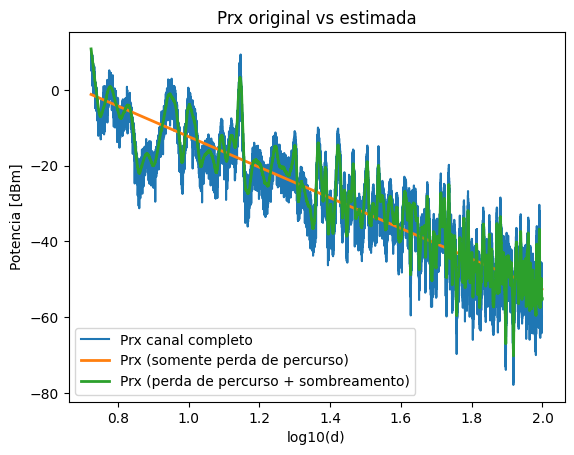

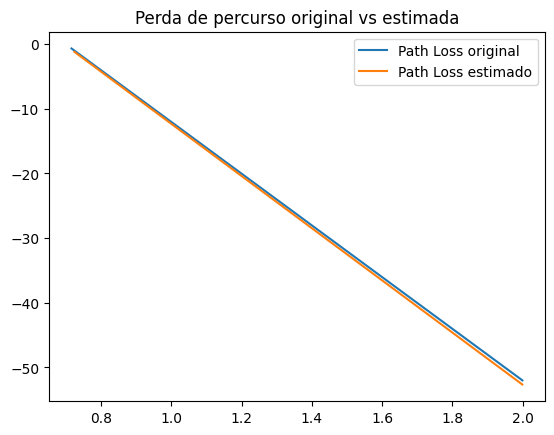

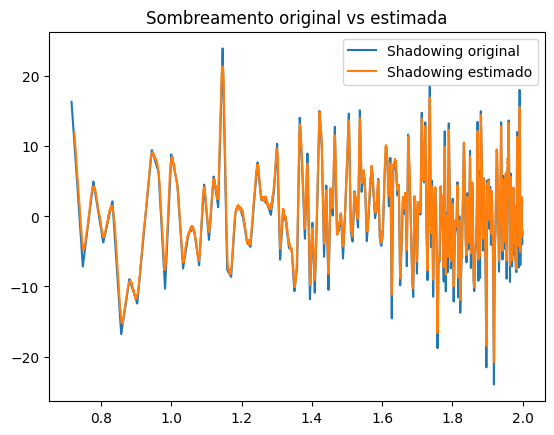

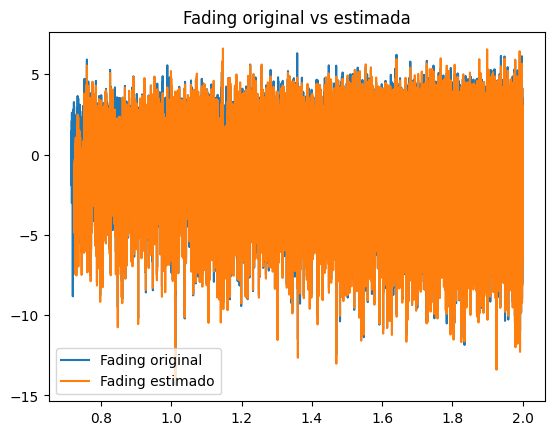

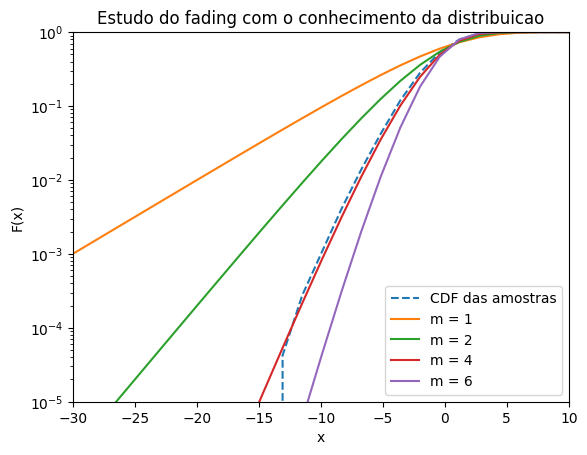

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.special import gamma, gammainc
from scipy.stats import nakagami


def fGeraCanal(sPar):
    d0 = sPar["d0"]
    totalLength = sPar["totalLength"]
    dMed = sPar["dMed"]
    n = sPar["n"]
    P0 = sPar["P0"]
    sigma = sPar["sigma"]
    shadowingWindow = sPar["shadowingWindow"]
    m = sPar["m"]
    txPower = sPar["txPower"]
    chFileName = sPar["chFileName"]

    vtDist = np.arange(d0, totalLength + dMed, dMed)
    nSamples = len(vtDist)
    vtPathLoss = P0 + 10 * n * np.log10(vtDist / d0)

    nShadowSamples = nSamples // shadowingWindow
    vtShadowing = sigma * np.random.randn(nShadowSamples)
    rest_len = nSamples % shadowingWindow
    restShadowing = sigma * np.random.randn() * np.ones(rest_len)
    vtShadowing = np.repeat(vtShadowing, shadowingWindow)
    vtShadowing = np.concatenate([vtShadowing, restShadowing])

    jan = shadowingWindow // 2
    vtShadCorr = np.array([
        np.mean(vtShadowing[i - jan:i + jan + 1])
        for i in range(jan, nSamples - jan)
    ])
    vtShadCorr = vtShadCorr * np.std(vtShadowing) / np.std(vtShadCorr)
    vtShadCorr = vtShadCorr - np.mean(vtShadCorr) + np.mean(vtShadowing)

    vtNakagamiNormEnvelope = nakagami.rvs(m, size=nSamples)
    vtNakagamiSampdB = 20 * np.log10(vtNakagamiNormEnvelope)

    vtTxPower = txPower * np.ones(nSamples)
    vtTxPower = vtTxPower[jan:nSamples - jan]
    vtPathLoss = vtPathLoss[jan:nSamples - jan]
    vtFading = vtNakagamiSampdB[jan:nSamples - jan]
    vtDist = vtDist[jan:nSamples - jan]
    vtPrxdBm = vtTxPower - vtPathLoss + vtShadCorr + vtFading

    savemat(
        chFileName + ".mat",
        {
            "vtDist": vtDist,
            "vtPathLoss": vtPathLoss,
            "vtShadCorr": vtShadCorr,
            "vtFading": vtFading,
            "vtPrxdBm": vtPrxdBm,
        },
    )

    return vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm


# Parametros para geracao do canal sintetico
sPar = {
    "d0": 5,
    "P0": 0,
    "nPoints": 50000,
    "totalLength": 100,
    "n": 4,
    "sigma": 6,
    "shadowingWindow": 200,
    "m": 4,
    "txPower": 0,
    "nCDF": 40,
    "dW": 100,
    "chFileName": "Prx_sintetico",
}

# Distancia entre pontos de medicao
sPar["dMed"] = sPar["totalLength"] / sPar["nPoints"]

# Chama funcao que gera o canal sintetico
vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm = fGeraCanal(sPar)

# Transforma potencia em mWatts
vtPtrxmW = 10 ** (vtPrxdBm / 10)
nSamples = len(vtPtrxmW)

# Vetores para canal estimado
vtDesLarga = []
vtDesPequeEst = []

# Calculo do desvanecimento lento e rapido
dMeiaJanela = round((sPar["dW"] - 1) / 2)
for ik in range(dMeiaJanela, nSamples - dMeiaJanela):
    vtDesLarga.append(10 * np.log10(np.mean(vtPtrxmW[ik - dMeiaJanela:ik + dMeiaJanela + 1])))
    vtDesPequeEst.append(vtPrxdBm[ik] - vtDesLarga[-1])

vtDesLarga = np.array(vtDesLarga)
vtDesPequeEst = np.array(vtDesPequeEst)

# Calculo da envoltoria normalizada (para efeitos de calculo do fading)
indexes = np.arange(dMeiaJanela, nSamples - dMeiaJanela)
vtPtrxmWNew = 10 ** (vtPrxdBm[indexes] / 10)
desLarga_Lin = 10 ** (vtDesLarga[: len(indexes)] / 10)
envNormal = np.sqrt(vtPtrxmWNew) / np.sqrt(desLarga_Lin)

# Ajuste no tamanho dos vetores devido a filtragem
vtDistEst = vtDist[indexes]
vtPrxdBmEst = vtPrxdBm[indexes]

# Calculo reta de perda de percurso
vtDistLog = np.log10(vtDist)
vtDistLogEst = np.log10(vtDistEst)
dCoefReta = np.polyfit(vtDistLogEst, vtPrxdBmEst, 1)
dNEst = -dCoefReta[0] / 10
print(f"Estimacao dos parametros de larga escala (W = {sPar['dW']}):")
print(f"   Expoente de perda de percurso estimado n = {dNEst:.4f}")

# Perda de percurso estimada para os pontos de medicao
vtPathLossEst = np.polyval(dCoefReta, vtDistLogEst)

# Sombreamento
vtShadCorrEst = vtDesLarga - vtPathLossEst
stdShad = np.std(vtShadCorrEst)
meanShad = np.mean(vtShadCorrEst)
print(f"   Desvio padrao do sombreamento estimado = {stdShad:.4f}")
print(f"   Media do sombreamento estimado = {meanShad:.4f}")

vtPathLossEst = -vtPathLossEst
vtPrxEst = sPar["txPower"] - vtPathLossEst + vtShadCorrEst + vtDesPequeEst

# Estimacao da CDF do desvanecimento de pequena escala
vtn = np.arange(1, sPar["nCDF"] + 1)
xCDF = (1.2 ** (vtn - 1)) * 0.01
cdffn = np.array([np.sum(envNormal <= x) for x in xCDF], dtype=float)

# Monta estrutura do histograma
xccdfEst = 20 * np.log10(xCDF)
yccdfEst = cdffn / cdffn[-1]

# Figuras do canal estimado
plt.figure()
plt.plot(vtDistLogEst, vtPrxEst, label="Prx canal completo")
plt.plot(vtDistLogEst, sPar["txPower"] - vtPathLossEst, linewidth=2, label="Prx (somente perda de percurso)")
plt.plot(vtDistLogEst, sPar["txPower"] - vtPathLossEst + vtShadCorrEst, linewidth=2, label="Prx (perda de percurso + sombreamento)")
plt.xlabel("log10(d)")
plt.ylabel("Potencia [dBm]")
plt.legend()
plt.title("Prx original vs estimada")

plt.figure()
plt.plot(vtDistLog, -vtPathLoss, label="Path Loss original")
plt.plot(vtDistLogEst, -vtPathLossEst, label="Path Loss estimado")
plt.legend()
plt.title("Perda de percurso original vs estimada")

plt.figure()
plt.plot(vtDistLog, vtShadCorr, label="Shadowing original")
plt.plot(vtDistLogEst, vtShadCorrEst, label="Shadowing estimado")
plt.legend()
plt.title("Sombreamento original vs estimada")

plt.figure()
plt.plot(vtDistLog, vtFading, label="Fading original")
plt.plot(vtDistLogEst, vtDesPequeEst, label="Fading estimado")
plt.legend()
plt.title("Fading original vs estimada")

# Plot das CDFs normalizadas Nakagami para varios valores de m
plt.figure()
plt.semilogy(xccdfEst, yccdfEst, "--", label="CDF das amostras")
vtm = [1, 2, 4, 6]
xCDF_lin = 10 ** (xccdfEst / 20)
for im in vtm:
    cdfnaka = gammainc(im, im * xCDF_lin**2)
    plt.semilogy(20 * np.log10(xCDF_lin), cdfnaka, label=f"m = {im}")
plt.axis([-30, 10, 1e-5, 1])
plt.title("Estudo do fading com o conhecimento da distribuicao")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.show()


## Prática 03: Influência da janela de filtragem para separação dos desvanecimentos de larga e pequena escalas e estimação da distribuição do fading

Vamos escrever um código para estimar o desvanecimento de pequena escala (sua distribuição e parâmetros) e investigar a influência do tamanho da janela de filtragem para separação dos desvanecimentos de larga e pequena escalas. O código irá aplicar alguns testes estatísticos e fará um estudo com o conhecimento a priori do canal e sem seu conhecimento.

O código a seguir cria uma função chamada **fGeraCanal.m** para gerar o canal sintético com parâmetros conhecidos. 

O código também cria uma função chamada **fEstimaCanal.m**, com o código da prática anterior em forma de função. Isso foi feito para melhor organizar o código da prática 03.

Assim, essa prática mantém o código da prática anterior e acrescenta:

1. A estimação da melhor janela pelo MSE da CDF do desvanecimento de pequena escala para vários valores de janela de filtragem e vários valores do $m$ de Nakagami (comparar com o resultado do passo anterior);
2. A aparesentação da CDF do desvanecimento de pequena escala para os vários valores de janela de filtragem.

Canal sintetico:
   Media do sombreamento: 0.2805
   Std do sombreamento: 6.5607
   Janela de correlacao do sombreamento: 200 amostras
   Expoente de path loss: 4
   m de Nakagami: 4
Estimacao dos parametros de larga escala (W = 10):
   Expoente de perda de percurso estimado n = 3.8531
   Desvio padrao do sombreamento estimado = 6.5670
   Media do sombreamento estimado = 0.5150
   MSE Shadowing = 0.6975
----

Estimacao dos parametros de larga escala (W = 50):
   Expoente de perda de percurso estimado n = 3.8493
   Desvio padrao do sombreamento estimado = 6.4881
   Media do sombreamento estimado = 0.6347
   MSE Shadowing = 0.4683
----

Estimacao dos parametros de larga escala (W = 150):
   Expoente de perda de percurso estimado n = 3.8366
   Desvio padrao do sombreamento estimado = 6.1454
   Media do sombreamento estimado = 1.1464
   MSE Shadowing = 2.2050
----

Estimacao dos parametros de larga escala (W = 200):
   Expoente de perda de percurso estimado n = 3.8280
   Desvio padrao do s

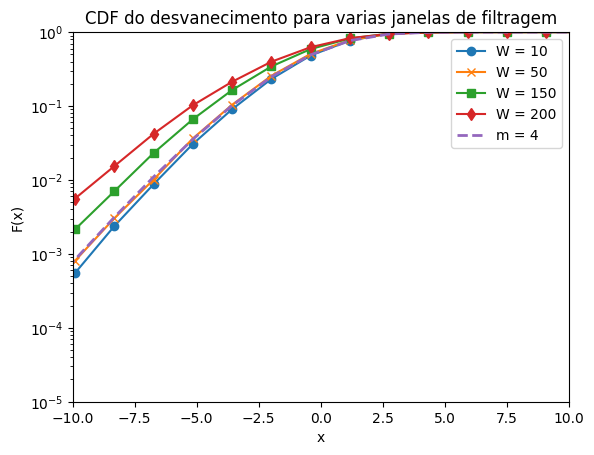

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy.special import gamma, gammainc
from scipy.stats import nakagami


def fGeraCanal(sPar):
    d0 = sPar["d0"]
    totalLength = sPar["totalLength"]
    dMed = sPar["dMed"]
    n = sPar["n"]
    P0 = sPar["P0"]
    sigma = sPar["sigma"]
    shadowingWindow = sPar["shadowingWindow"]
    m = sPar["m"]
    txPower = sPar["txPower"]
    chFileName = sPar["chFileName"]
    vtDist = np.arange(d0, totalLength + dMed, dMed)
    nSamples = len(vtDist)
    vtPathLoss = P0 + 10 * n * np.log10(vtDist / d0)
    nShadowSamples = nSamples // shadowingWindow
    vtShadowing = sigma * np.random.randn(nShadowSamples)
    rest_len = nSamples % shadowingWindow
    restShadowing = sigma * np.random.randn() * np.ones(rest_len)
    vtShadowing = np.repeat(vtShadowing, shadowingWindow)
    vtShadowing = np.concatenate([vtShadowing, restShadowing])
    jan = shadowingWindow // 2
    vtShadCorr = np.array([
        np.mean(vtShadowing[i - jan:i + jan + 1])
        for i in range(jan, nSamples - jan)
    ])
    vtShadCorr = vtShadCorr * np.std(vtShadowing) / np.std(vtShadCorr)
    vtShadCorr = vtShadCorr - np.mean(vtShadCorr) + np.mean(vtShadowing)
    vtNakagamiNormEnvelope = nakagami.rvs(m, size=nSamples)
    vtNakagamiSampdB = 20 * np.log10(vtNakagamiNormEnvelope)
    vtTxPower = txPower * np.ones(nSamples)
    vtTxPower = vtTxPower[jan:nSamples - jan]
    vtPathLoss = vtPathLoss[jan:nSamples - jan]
    vtFading = vtNakagamiSampdB[jan:nSamples - jan]
    vtDist = vtDist[jan:nSamples - jan]
    vtPrxdBm = vtTxPower - vtPathLoss + vtShadCorr + vtFading
    savemat(
        chFileName + ".mat",
        {"vtDist": vtDist, "vtPathLoss": vtPathLoss, "vtShadCorr": vtShadCorr,
         "vtFading": vtFading, "vtPrxdBm": vtPrxdBm},
    )
    return vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm


def fEstimaCanal(sPar):
    data = loadmat(sPar["chFileName"] + ".mat")
    vtDist = data["vtDist"].flatten()
    vtPrxdBm = data["vtPrxdBm"].flatten()
    vtPtrxmW = 10 ** (vtPrxdBm / 10)
    nSamples = len(vtPtrxmW)
    vtDesLarga = []
    vtDesPequeEst = []
    dMeiaJanela = sPar["dW"] // 2
    for ik in range(dMeiaJanela, nSamples - dMeiaJanela):
        lv = 10 * np.log10(np.mean(vtPtrxmW[ik - dMeiaJanela:ik + dMeiaJanela + 1]))
        vtDesLarga.append(lv)
        vtDesPequeEst.append(vtPrxdBm[ik] - lv)
    vtDesLarga = np.array(vtDesLarga)
    vtDesPequeEst = np.array(vtDesPequeEst)
    indexes = np.arange(dMeiaJanela, nSamples - dMeiaJanela)
    vtPtrxmWNew = 10 ** (vtPrxdBm[indexes] / 10)
    desLarga_Lin = 10 ** (vtDesLarga[:len(indexes)] / 10)
    vtEnvNorm = np.sqrt(vtPtrxmWNew) / np.sqrt(desLarga_Lin)
    vtDistEst = vtDist[indexes]
    vtPrxdBmEst = vtPrxdBm[indexes]
    vtDistLogEst = np.log10(vtDistEst)
    dCoefReta = np.polyfit(vtDistLogEst, vtPrxdBmEst, 1)
    dNEst = -dCoefReta[0] / 10
    vtPathLossEst = np.polyval(dCoefReta, vtDistLogEst)
    vtShadCorrEst = vtDesLarga - vtPathLossEst
    dStdShadEst = np.std(vtShadCorrEst)
    dStdMeanShadEst = np.mean(vtShadCorrEst)
    vtPathLossEst = -vtPathLossEst
    vtPrxEst = sPar["txPower"] - vtPathLossEst + vtShadCorrEst + vtDesPequeEst
    vtn = np.arange(1, sPar["nCDF"] + 1)
    xCDF = (1.2 ** (vtn - 1)) * 0.01
    cdffn = np.array([np.sum(vtEnvNorm <= x) for x in xCDF], dtype=float)
    vtXCcdfEst = 20 * np.log10(xCDF)
    vtYCcdfEst = cdffn / cdffn[-1]
    return {
        "vtDistEst": vtDistEst,
        "vtPathLossEst": vtPathLossEst,
        "dNEst": dNEst,
        "vtShadCorrEst": vtShadCorrEst,
        "dStdShadEst": dStdShadEst,
        "dStdMeanShadEst": dStdMeanShadEst,
        "vtDesPequeEst": vtDesPequeEst,
        "vtPrxEst": vtPrxEst,
        "vtXCcdfEst": vtXCcdfEst,
        "vtYCcdfEst": vtYCcdfEst,
        "vtEnvNorm": vtEnvNorm,
    }


# Parametros para geracao do canal sintetico
sPar = {
    "d0": 5, "P0": 0, "nPoints": 50000, "totalLength": 100,
    "n": 4, "sigma": 6, "shadowingWindow": 200, "m": 4,
    "txPower": 0, "nCDF": 40, "dW": 100, "chFileName": "Prx_sintetico",
}
sPar["dMed"] = sPar["totalLength"] / sPar["nPoints"]

# Gera canal sintetico
vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm = fGeraCanal(sPar)

print("Canal sintetico:")
print(f"   Media do sombreamento: {np.mean(vtShadCorr):.4f}")
print(f"   Std do sombreamento: {np.std(vtShadCorr):.4f}")
print(f"   Janela de correlacao do sombreamento: {sPar['shadowingWindow']} amostras")
print(f"   Expoente de path loss: {sPar['n']}")
print(f"   m de Nakagami: {sPar['m']}")

# Varias janelas de filtragem para testar a estimacao
vtW = [10, 50, 150, 200]
sOut = []
vtMSEShad = []
vtMSEFad = []

for dW in vtW:
    sPar["dW"] = dW
    out = fEstimaCanal(sPar)
    sOut.append(out)
    dMeiaJanela = dW // 2
    vtShadCorr_trim = vtShadCorr[dMeiaJanela:len(vtShadCorr) - dMeiaJanela]
    vtFading_trim = vtFading[dMeiaJanela:len(vtFading) - dMeiaJanela]
    mseShad = np.mean((vtShadCorr_trim - out["vtShadCorrEst"]) ** 2)
    mseFad = np.mean((vtFading_trim - out["vtDesPequeEst"]) ** 2)
    vtMSEShad.append(mseShad)
    vtMSEFad.append(mseFad)
    print(f"Estimacao dos parametros de larga escala (W = {dW}):")
    print(f"   Expoente de perda de percurso estimado n = {out['dNEst']:.4f}")
    print(f"   Desvio padrao do sombreamento estimado = {out['dStdShadEst']:.4f}")
    print(f"   Media do sombreamento estimado = {out['dStdMeanShadEst']:.4f}")
    print(f"   MSE Shadowing = {mseShad:.4f}")
    print("----")
    print()

# Estudo da melhor janela de filtragem
print("Estudo na melhor janela de filtragem")
print(f"   Janelas utilizadas = {vtW}")
posBestShad = int(np.argmin(vtMSEShad))
print("   Melhor MSE relativo aos valores reais do Shadowing (melhor janela):")
print(f"      Melhor janela W = {vtW[posBestShad]}: MSE Shadowing = {vtMSEShad[posBestShad]:.4f}")
posBestFad = int(np.argmin(vtMSEFad))
print("   Melhor MSE relativo aos valores reais do Fading:")
print(f"      Melhor janela W = {vtW[posBestFad]}: MSE Fading = {vtMSEFad[posBestFad]:.4f}")
print("-" * 82)

# Plot das CDFs do desvanecimento para cada janela + Nakagami teorica (m original)
chMarkers = ["o-", "x-", "s-", "d-"]
xCDF = 10 ** (sOut[0]["vtXCcdfEst"] / 20)
plt.figure()
legend_labels = []
for iw, dW in enumerate(vtW):
    plt.semilogy(sOut[iw]["vtXCcdfEst"], sOut[iw]["vtYCcdfEst"], chMarkers[iw])
    legend_labels.append(f"W = {dW}")
m_orig = sPar["m"]
cdfnaka_orig = gammainc(m_orig, m_orig * xCDF ** 2)
plt.semilogy(20 * np.log10(xCDF), cdfnaka_orig, "--", linewidth=2)
legend_labels.append(f"m = {m_orig}")
plt.legend(legend_labels)
plt.axis([-10, 10, 1e-5, 1])
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF do desvanecimento para varias janelas de filtragem")

# Calculo do MSE da CDF com varias janelas de filtragem e varios valores de m
print("MSE da CDF com varias janelas de filtragem com o conhecimento do Fading:")
vtm = list(range(2, 6))  # [2, 3, 4, 5]
mtMSEFad = np.zeros((len(vtm), len(vtW)))
for ik, im in enumerate(vtm):
    cdfnaka = gammainc(im, im * xCDF ** 2)
    for il, dW in enumerate(vtW):
        mtMSEFad[ik, il] = np.mean((cdfnaka - sOut[il]["vtYCcdfEst"]) ** 2)
        print(f"   m = {im}, W = {dW}: MSE Fading = {mtMSEFad[ik, il]:.6f}")
    print("----")

posLinha = np.argmin(mtMSEFad, axis=0)
vLinha = np.min(mtMSEFad, axis=0)
bestCol = int(np.argmin(vLinha))
bestLin = int(posLinha[bestCol])
print("   Melhor MSE relativo aos valores reais do fading:")
print(f"   W = {vtW[bestCol]} e m = {vtm[bestLin]}: MSE Fading = {mtMSEFad[bestLin, bestCol]:.6f}")
print("-" * 82)
plt.show()


Até esse momento nos concentramos em estimar os parâmetros do canal com o conhecimento a priori da série temporal do sombreamento e do desvanecimento de pequena escala. Contudo, para estimação de canal baseado em uma medição de campo (e não de um sinal sintético), esse conhecimento não é possível. Na verdade, conhecer as características estatísticas dessas séries temporais é a grande tarefa da estimação.  

Um método muito utilizado para estimação de parâmetros é o MLE (Maximum Likelihood Estimation). O MLE é um método de estimar os parâmetros ${\theta}$ de uma específica função distribuição de probabilidades $f(x_{i}|{\theta})$ de uma variável aleatória $X$ [[Fonte]](http://times.cs.uiuc.edu/course/410/note/mle.pdf). A estimação é baseada em amostras i.i.d. (independent and identically distributed) $x_{i}$ e na função  log-likelihood (máxima verossimilhança) definida como:

&nbsp; 
$\ell({\theta}) = \sum_{i=1}^{N} \log f (x_{i}| {\theta})$.


Então, o MLE escolhe os parâmetros $\hat{\theta}$ que maximiza a função de máxima verossimilhança, resultando nos parâmetros mais prováveis de gerar os dados observados [[Fonte]](https://www.jstage.jst.go.jp/article/iis/17/3/17_3_155/_pdf/-char/en).

Especificamente no MatLab, a função **fitdist** foi contruída para fazer o MLE [[Fonte]](https://www.mathworks.com/help/stats/fitdist.html#btu538h-pd). O código em Python usa **scipy.stats** para MLE, equivalente ao fitdist do MATLAB.


O código a seguir é o mesmo código da prática anterior, acrescentando:

1. A estimação via MLE os parâmetros das distribuição Nakagami, Rice, Rayleigh e Weibull para os dados do desvanecimento de pequena escala estimado para as várias janelas;
2. Além de constatar a possibilidade de parâmetros de para cada distribuição, inspecionaremos quais os parâmetros estimados para Nakagami, já que sabemos que esse é o tipo de canal gerado.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy.special import gammainc
from scipy.stats import nakagami, rice, rayleigh, weibull_min


def fGeraCanal(sPar):
    from scipy.stats import nakagami as _nakagami
    d0 = sPar["d0"]; totalLength = sPar["totalLength"]; dMed = sPar["dMed"]
    n = sPar["n"]; P0 = sPar["P0"]; sigma = sPar["sigma"]
    shadowingWindow = sPar["shadowingWindow"]; m = sPar["m"]
    txPower = sPar["txPower"]; chFileName = sPar["chFileName"]
    vtDist = np.arange(d0, totalLength + dMed, dMed)
    nSamples = len(vtDist)
    vtPathLoss = P0 + 10 * n * np.log10(vtDist / d0)
    nShadowSamples = nSamples // shadowingWindow
    vtShadowing = sigma * np.random.randn(nShadowSamples)
    rest_len = nSamples % shadowingWindow
    restShadowing = sigma * np.random.randn() * np.ones(rest_len)
    vtShadowing = np.repeat(vtShadowing, shadowingWindow)
    vtShadowing = np.concatenate([vtShadowing, restShadowing])
    jan = shadowingWindow // 2
    vtShadCorr = np.array([np.mean(vtShadowing[i - jan:i + jan + 1]) for i in range(jan, nSamples - jan)])
    vtShadCorr = vtShadCorr * np.std(vtShadowing) / np.std(vtShadCorr)
    vtShadCorr = vtShadCorr - np.mean(vtShadCorr) + np.mean(vtShadowing)
    vtNakagamiNormEnvelope = _nakagami.rvs(m, size=nSamples)
    vtNakagamiSampdB = 20 * np.log10(vtNakagamiNormEnvelope)
    vtTxPower = txPower * np.ones(nSamples)
    vtTxPower = vtTxPower[jan:nSamples - jan]
    vtPathLoss = vtPathLoss[jan:nSamples - jan]
    vtFading = vtNakagamiSampdB[jan:nSamples - jan]
    vtDist = vtDist[jan:nSamples - jan]
    vtPrxdBm = vtTxPower - vtPathLoss + vtShadCorr + vtFading
    savemat(chFileName + ".mat", {"vtDist": vtDist, "vtPathLoss": vtPathLoss,
        "vtShadCorr": vtShadCorr, "vtFading": vtFading, "vtPrxdBm": vtPrxdBm})
    return vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm


def fEstimaCanal(sPar):
    data = loadmat(sPar["chFileName"] + ".mat")
    vtDist = data["vtDist"].flatten()
    vtPrxdBm = data["vtPrxdBm"].flatten()
    vtPtrxmW = 10 ** (vtPrxdBm / 10)
    nSamples = len(vtPtrxmW)
    vtDesLarga = []; vtDesPequeEst = []
    dMeiaJanela = sPar["dW"] // 2
    for ik in range(dMeiaJanela, nSamples - dMeiaJanela):
        lv = 10 * np.log10(np.mean(vtPtrxmW[ik - dMeiaJanela:ik + dMeiaJanela + 1]))
        vtDesLarga.append(lv)
        vtDesPequeEst.append(vtPrxdBm[ik] - lv)
    vtDesLarga = np.array(vtDesLarga); vtDesPequeEst = np.array(vtDesPequeEst)
    indexes = np.arange(dMeiaJanela, nSamples - dMeiaJanela)
    vtPtrxmWNew = 10 ** (vtPrxdBm[indexes] / 10)
    desLarga_Lin = 10 ** (vtDesLarga[:len(indexes)] / 10)
    vtEnvNorm = np.sqrt(vtPtrxmWNew) / np.sqrt(desLarga_Lin)
    vtDistEst = vtDist[indexes]; vtPrxdBmEst = vtPrxdBm[indexes]
    vtDistLogEst = np.log10(vtDistEst)
    dCoefReta = np.polyfit(vtDistLogEst, vtPrxdBmEst, 1)
    dNEst = -dCoefReta[0] / 10
    vtPathLossEst = np.polyval(dCoefReta, vtDistLogEst)
    vtShadCorrEst = vtDesLarga - vtPathLossEst
    dStdShadEst = np.std(vtShadCorrEst); dStdMeanShadEst = np.mean(vtShadCorrEst)
    vtPathLossEst = -vtPathLossEst
    vtPrxEst = sPar["txPower"] - vtPathLossEst + vtShadCorrEst + vtDesPequeEst
    vtn = np.arange(1, sPar["nCDF"] + 1)
    xCDF = (1.2 ** (vtn - 1)) * 0.01
    cdffn = np.array([np.sum(vtEnvNorm <= x) for x in xCDF], dtype=float)
    vtXCcdfEst = 20 * np.log10(xCDF); vtYCcdfEst = cdffn / cdffn[-1]
    return {"vtDistEst": vtDistEst, "vtPathLossEst": vtPathLossEst, "dNEst": dNEst,
            "vtShadCorrEst": vtShadCorrEst, "dStdShadEst": dStdShadEst,
            "dStdMeanShadEst": dStdMeanShadEst, "vtDesPequeEst": vtDesPequeEst,
            "vtPrxEst": vtPrxEst, "vtXCcdfEst": vtXCcdfEst,
            "vtYCcdfEst": vtYCcdfEst, "vtEnvNorm": vtEnvNorm}


# Parametros para geracao do canal sintetico
sPar = {
    "d0": 5, "P0": 0, "nPoints": 50000, "totalLength": 100,
    "n": 4, "sigma": 6, "shadowingWindow": 200, "m": 4,
    "txPower": 0, "nCDF": 40, "dW": 100, "chFileName": "Prx_sintetico",
}
sPar["dMed"] = sPar["totalLength"] / sPar["nPoints"]

# Gera canal sintetico
vtDist, vtPathLoss, vtShadCorr, vtFading, vtPrxdBm = fGeraCanal(sPar)

print("Canal sintetico:")
print(f"   Media do sombreamento: {np.mean(vtShadCorr):.4f}")
print(f"   Std do sombreamento: {np.std(vtShadCorr):.4f}")
print(f"   Janela de correlacao do sombreamento: {sPar['shadowingWindow']} amostras")
print(f"   Expoente de path loss: {sPar['n']}")
print(f"   m de Nakagami: {sPar['m']}")

# Varias janelas de filtragem para testar a estimacao
vtW = [10, 50, 150, 200]
sOut = []
for dW in vtW:
    sPar["dW"] = dW
    sOut.append(fEstimaCanal(sPar))

# Estimacao cega via MLE (equivalente ao fitdist do MATLAB)
print()
print("Estimacao do Fading para varias janelas (estudo numerico sem conhecimento a priori do canal)")
print("Resultados com scipy.stats (MLE)")
for iw, dW in enumerate(vtW):
    envNorm = sOut[iw]["vtEnvNorm"]
    print(f"Janela W = {dW}")

    # Nakagami MLE: nakagami(nu, loc, scale) -> m=nu, omega=scale^2
    nu, loc_n, scale_n = nakagami.fit(envNorm, floc=0)
    omega = scale_n ** 2
    print(f"  Nakagami: m = {nu:.4f}, omega = {omega:.4f}")

    # Rice MLE: rice(b, loc, scale) -> K = b^2/2
    b, loc_r, scale_r = rice.fit(envNorm, floc=0)
    K_rice = b ** 2 / 2
    print(f"  Rice: K = {K_rice:.4f}")

    # Rayleigh MLE: rayleigh(loc, scale) -> sigma = scale
    loc_ray, scale_ray = rayleigh.fit(envNorm, floc=0)
    print(f"  Rayleigh: sigma = {scale_ray:.4f}")

    # Weibull MLE: weibull_min(c, loc, scale) -> k=c, lambda=scale
    c, loc_w, scale_w = weibull_min.fit(envNorm, floc=0)
    print(f"  Weibull: k = {c:.4f}, lambda = {scale_w:.4f}")
    print()


Canal sintetico:
   Media do sombreamento: 0.3452
   Std do sombreamento: 6.0187
   Janela de correlacao do sombreamento: 200 amostras
   Expoente de path loss: 4
   m de Nakagami: 4

Estimacao do Fading para varias janelas (estudo numerico sem conhecimento a priori do canal)
Resultados com scipy.stats (MLE)
Janela W = 10
  Nakagami: m = 4.3150, omega = 0.9995
  Rice: K = 7.6469
  Rayleigh: sigma = 0.7069
  Weibull: k = 4.4714, lambda = 1.0634

Janela W = 50
  Nakagami: m = 4.0112, omega = 0.9856
  Rice: K = 6.9876
  Rayleigh: sigma = 0.7020
  Weibull: k = 4.2680, lambda = 1.0563

Janela W = 150
  Nakagami: m = 3.4242, omega = 0.9185
  Rice: K = 5.7233
  Rayleigh: sigma = 0.6777
  Weibull: k = 3.8653, lambda = 1.0195

Janela W = 200
  Nakagami: m = 2.9109, omega = 0.8900
  Rice: K = 4.6447
  Rayleigh: sigma = 0.6671
  Weibull: k = 3.5239, lambda = 1.0020



**A execução do código resulta em:**
1. Mensagens de texto com informações sobre o canal sintético gerado;
2. Mensagens de texto com informações sobre os parâmetros das distribuições Nakagami, Rice, Rayleigh e Weibull que melhor se adequam aos dados do desvanecimento de pequena escala. Observe que a melhor janela é W = 50, que o $m$ d Nakagami é exatamente igual a 4.

**Analise o código com cuidado. Tente compreender a modelagem e a sintaxe usada. Discuta com os colegas. Faça um debug usando sua IDE preferida.**


# Entrega 01: Análise de uma medição real (caracterização de canais banda estreita)


## Descrição da entrega

Tudo até agora foi feito com base em um sinal sintético gerado via simulação. Modifique o código disponibilizado para manipular o arquivo [**Prx_Real_2026_1.mat**](./CODES/HD_03_MATLAB/Prx_Real_2026_1.mat) e estimar o expoente de perda de percurso e o desvio padrão do sombreamento. 

O arquivo contém as seguintes variáveis:
- **dPath**: pontos de medição [m] - um vetor com 200 amostras
- **Prx**: potência recebida com o canal completo. Um vetor com 200 amostras, correspondentes aos pontos de medição. Unidade em dBm.

Os seguintes gráficos devem ser disponibilizados.

   1. Plotar no mesmo gráfico as curvas: potência recebida completa (sujeita ao desvanecimento de larga e pequena escalas) vs distância; potência recebida somente sujeita ao path loss estimado vs distância; potência recebida somente sujeita ao path loss e ao sombreamento estimados vs distância. Identificar as linhas por legendas e cores diferentes. A curvas devem ser feitas em função da distância percorrida na medição. Use W = 5.
   2. Fazer a estimativa para os seguintes valores da janela W = 2, 5, 10. Fazer uma tabela com o seguinte formato:

|Janela | Desvio padrão do sombreamento estimado | Média do sombreamento estimado |	Expoente de perda de percurso estimado |
|-----------------	|------------------	|-----------------	|-----------------	|
|W = 2 | | | |			
|W = 5 | | | |			
|W = 10 | | | |			

   3. Use um programa de PDF fitting (e.g. o Easyfit) e carregue os dados do desvanecimento de pequena escala. Mostre qual é a melhor distribuição (e seus parâmetros) para cada janela de filtragem simulada. Apresente e discuta a seguinte tabela:

|Janela	| Primeira melhor PDF | Parâmetro(s) da primeira melhor PDF |	Segunda melhor PDF |	Parâmetro(s) da segunda melhor PDF|
|-----------------	|------------------	|-----------------	|-----------------	| -----------------	|
|W = 2 | | | |  |				
|W = 5 | | | |	 |			
|W = 10 | | | |	 |			